# COGS 108 - Data Checkpoint

## Authors

- Siya Kamboj: Conceptualization, Data Curation, Methodology, Writing - original draft
- Vivian Zhu: Background research, Experimental investigation, Writing - original draft
- Kaitlyn Tam: Background research, Methodology, Writing - original draft
- Ludwig Von Schoenfeldt: Conceptualization, Experimental investigation, Software, Writing – review & editing
- Phillip Schiffman: Experimental investigation, Visualization, Writing - review & editing

## Research Question

Our project analyzes which financial news type’s sentiment is the strongest predictor of stock price movement for NVIDIA in May & June of 2023. We will use a dataset containing news headlines from multiple sources, each labeled with a sentiment polarity score and publication date, along with NVIDIA’s daily stock returns. For each source, we will calculate daily average sentiment and match it with same-day and next-day stock returns. The main variables include sentiment polarity, daily percent return, and price volatility. We will use correlation analysis and multiple linear regression to compare how well each source’s sentiment predicts stock behavior.

## Background and Prior Work

As new information enters the market and shapes expectations, stock prices often move in response to news. Since the COVID-19 period, markets have become faster, with news spreading almost instantly across different platforms. This highlights how financial news has become an important factor in influencing stock price movements. Focusing on the influence of financial news sentiment in stock price movements, our research question is: “Which financial news source’s sentiment is the strongest predictor of stock price movement for NVIDIA in the post-COVID period?”

During the early stages of the pandemic, global stock markets experienced declines, and investor expectations were changing frequently. The unusual news events changed up the usual market patterns, making prices more unpredictable.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) This suggests that after COVID, markets respond to news more quickly, which is why looking at the sentiment of financial news can be useful for understanding stock price movements.

The relationship between news sentiment and stock price movements has been studied on a large-scale in financial economics. A study by Tetlock demonstrates that media sentiment can influence stock prices by analyzing daily Wall Street Journal content. He found that highly negative news often leads to price drops, and unusual sentiment drives higher trading, showing that news can predict the market.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)  This supports the idea that different sources’ sentiment may have measurable effects on prices, which we aim to analyze for NVIDIA.

A recent study by Gao et al. finds that investor attention, measured through sentiment from multiple news providers, can affect stock returns. <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) For example when attention rises, prices often move in predictable ways, showing that variations in news attention can influence short-term market behavior. Additionally Cristescu et al. analyze how sentiment polarity from financial news titles and descriptions correlates with stock price changes for major tech companies, showing measurable connections and illustrating ways to analyze sentiment versus price. <a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)

Looking at more recent studies, they compare sentiment across multiple news sources to see which best predicts stock movements. For example, one study uses machine learning to weigh the impact of different sources, showing that some news outlets are more useful than others for forecasting. Building on these findings, our project will analyze the pre-existing sentiment scores from multiple financial news sources to determine which is most predictive of NVIDIA’s stock price, without developing new sentiment models.


1. <a name="cite_note-1"></a> Gormsen, N., & Koijen, R. (2020, March 26). How the Coronavirus Affects Stock Prices and Growth Expectations. The University of Chicago Booth School of Business. https://www.chicagobooth.edu/review/how-coronavirus-affects-stock-prices-and-growth-expectations

2. <a name="cite_note-2"></a> Tetlock, P. C. (2005). Giving Content to Investor Sentiment: The Role of Media in the Stock Market. SSRN Electronic Journal. https://doi.org/10.2139/ssrn.685145

3. <a name="cite_note-3"></a> Gao, R., Cui, S., Xiao, H., Fan, W., Zhang, H., & Wang, Y. (2022). Integrating the sentiments of multiple news providers for stock market index movement prediction: A deep learning approach based on evidential reasoning rule. Information Sciences, 615, 529–556. https://doi.org/10.1016/j.ins.2022.10.029

4. <a name="cite_note-4"></a> Cristescu, M. P., Mara, D. A., Nerișanu, R. A., Culda, L. C., & Maniu, I. (2023). Analyzing the Impact of Financial News Sentiments on Stock Prices—A Wavelet Correlation. Mathematics, 11(23), 4830. https://doi.org/10.3390/math11234830

## Hypothesis


We hypothesize that news sentiment from major, high-credibility financial news sources will be significantly correlated with NVIDIA’s short-term stock returns, particularly next-day returns, while sentiment from smaller or less specialized outlets will show weaker or no consistent relationship.

We will attempt to separate the news sources into major, high credibility ones and others by researching the amount of viewership and attention each news source gets. If a particular news source has x amount of viewership, we can assume they are credible and therefore ass it to our high credibility list.

We expect this outcome because large financial news organizations are more widely read by institutional and retail investors and tend to report information more quickly and consistently. As a result, their sentiment is more likely to influence market behavior or reflect information that is rapidly incorporated into stock prices. In contrast, smaller or more opinion-driven sources may publish content that is less timely or less impactful on investor decisions, leading to noisier or insignificant relationships with stock returns.

## Data

### Data overview

- Dataset #1
  - Dataset Name: Financial News with Ticker-Level Sentiment

  - Link to the dataset: https://www.kaggle.com/datasets/rdolphin/financial-news-with-ticker-level-sentiment?resource=download

  - Number of observations: The full dataset contains many observations; however, due to free-tier API limits, only 1000 NVIDIA-related articles (May–June 2023) could be downloaded. We also had to exclude a publisher that did not fit the clustering scheme (GlobeNewswire Inc., 18 articles), so the working dataset contains 982 observations.

  - Number of variables: 7 variables (published_utc, publisher, title, description, article_url, source, insights) were given in the dataset, and 5 variables (publisher_cluster, sentiment_model, sentiment_label, sentiment_score, sentiment_detail) were generated by us for preprocessing 

  - Description of the variables most relevant to this project: The most relevant variables for this project are the ones we generated during preprocessing. After listing all unique publisher names in the dataset, we grouped them into three clusters based on the style of coverage. The Motley Fool and Seeking Alpha were classified as Opinion / Retail Analysis, Zacks Investment Research as Quant / Analyst, and MarketWatch, Benzinga, and Investing.com as Real-Time News. This grouping is stored in the publisher_cluster variable and allows us to analyze sentiment by type of source rather than individual publisher to give us more data and robust analysis. We also generated sentiment variables using the VADER model, including sentiment_score (−1 to 1), sentiment_label (positive, neutral, negative), and sentiment_detail. These provide the main signal used to compare with stock price movement in dataset #2. Finally, the original published_utc timestamp is important because it lets us merge the news data with Dataset #2 and group by date.

  - Descriptions of any shortcomings this dataset has with repsect to the project:
    - The free-tier API does not provide ticker-level sentiment insights, so the `insights` field is null for all observations.Hence, sentiment scores were generated using the VADER model, which is not specifically fine-tuned for financial text. This may produce less accurate sentiment estimates compared to finance-specific models which are harder to access on a free tier.  
    - The dataset covers only a two-month period (May–June 2023). Results may therefore not generalize to other time periods especially if there were other real-world factors during that time (ie WHO just announced that COVID was no longer a public health emergency in May 2023).
    - The sample is limited to the first 1000 available articles due to the free tier of the API, which may introduce sampling bias.

- Dataset #2
  - Dataset Name: 
    - Massive Yahoo Finance Dataset
  - Link to the dataset: 
    - https://www.kaggle.com/datasets/iveeaten3223times/massive-yahoo-finance-dataset
  - Number of observations: 
    - ~1+ million daily records (varies by ticker; ~500 companies over ~5 years)
  - Number of variables: 
    - Typically 7 core variables per record: (Date, Open, High, Low, Close, Adjusted Close, Volume)
  - Description of the variables most relevant to this project: 
    - Date – trading day; used to align stock prices with sentiment timestamps
    - Ticker – identifies the company; used for merging with sentiment data
    - Open / High / Low / Close – daily price movement indicators
    - Adjusted Close – price adjusted for splits/dividends; best for return calculations
    - Volume – trading activity; can indicate market reaction intensity
  - Descriptions of any shortcomings this dataset has with repsect to the project:
    - Covers only ~5 years of data, limiting long-term trend analysis.
    - Contains daily frequency data only, making it difficult to study intraday sentiment reactions.
    - Focuses on large-cap companies (~top 500), which may bias results toward highly liquid stocks.
    - Does not include macroeconomic indicators, fundamentals, or market news context — these must be sourced separately.
    - Market holidays and missing trading days require alignment with sentiment timestamps.

Since we have 2 different datasets, we will be joining them on date to see the correlation between overall sentiment for a day and stock changes on that day. For instance, the yfinance dataset has 43 rows for the 43 different trading days, and the first dataset has published_utc as a field for which day/time that every article was published.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [4]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1U45CYCUOw1FzCrxRMvfLDeN7yo1mpQhy', 'filename':'stock_sentiment_1000.json'},
    { 'url': 'https://drive.google.com/uc?export=download&id=1nMg2pbuGvVCy2ZMPrEDBf2_DdrqQDUOg', 'filename':'stock_details_5_years.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:02<00:02,  2.17s/it]

Successfully downloaded: stock_sentiment_1000.json


Overall Download Progress: 100%|██████████| 2/2 [00:08<00:00,  4.35s/it]

Successfully downloaded: stock_details_5_years.csv


### NVDA Sentiment Analysis Dataset (May & June 2023)

This dataset consists of financial news articles related to NVIDIA (NVDA) published during May and June 2023. Each observation corresponds to a single article and includes information originally provided by the news API, such as the publication timestamp (`published_utc`), publisher metadata (`publisher` object with name and URLs), article headline (`title`), short summary (`description`), a link to the full article (`article_url`), and the publisher name as a string (`source`). The timestamp is recorded in Coordinated Universal Time (UTC) using ISO-8601 format and indicates when the article was published. These variables describe the content, source, and timing of each news item but do not directly quantify market impact. The dataset also includes an `insights` field that is supposed to contain ticker-level sentiment analysis; however, this field is null for all observations under the free-tier API.

The main concern with this dataset is that it lacks built-in sentiment information under the free tier, which is important to the project’s goal of analyzing how news tone relates to stock price movement. In addition, the dataset is limited to approximately 1000 articles due to API restrictions, which may not represent all NVDA-related news during this period. The coverage is also confined to a two-month window that could coincide with other world events that could have affected the overall stock trends. To address these limitations, we generate our own sentiment scores from the article text using vader model in the code below. Additionally, we don't have that much information from individual publishers, so we grouped publishers by content type and added a field called "publisher_cluster," where Opinion_Retail cluster contains "The Motley Fool" & "Seeking Alpha", Quant_Analyst cluster contains "Zacks Investment Research", and RealTime_News cluster contains "MarketWatch" & "Benzinga" & "Investing.com". 


3. Use the cell below to 
    1. load the dataset 
    2. make the dataset tidy or demonstrate that it was already tidy
    3. demonstrate the size of the dataset
    4. find out how much data is missing, where its missing, and if its missing at random or seems to have any systematic relationships in its missingness
    5. find and flag any outliers or suspicious entries
    6. clean the data or demonstrate that it was already clean.  You may choose how to deal with missingness (dropna of fillna... how='any' or 'all') and you should justify your choice in some way
    7. You will load raw data from `data/00-raw/`, you will (optionally) write intermediate stages of your work to `data/01-interim` and you will write the final fully wrangled version of your data to `data/02-processed`
4. Optionally you can also show some summary statistics for variables that you think are important to the project
5. Feel free to add more cells here if that's helpful for you


In [ ]:
import json
from collections import Counter
### LOAD THE DATASET
with open("data/00-raw/stock_sentiment_1000.json", "r", encoding="utf-8") as f:
    items = json.load(f)

In [6]:
### STEP 1: CREATE PUBLISHER CLUSTER
CLUSTER_MAP = {
    # Opinion / Retail Analysis
    "The Motley Fool": "Opinion_Retail",
    "Seeking Alpha": "Opinion_Retail",
    # Quant / Analyst
    "Zacks Investment Research": "Quant_Analyst",
    # Real-Time News
    "MarketWatch": "RealTime_News",
    "Benzinga": "RealTime_News",
    "Investing.com": "RealTime_News",
}
filtered_items = []
for item in items:
    src = item.get("source")
    cluster = CLUSTER_MAP.get(src)
    if cluster is not None:   # keeps only chosen groups
        item["publisher_cluster"] = cluster
        filtered_items.append(item)
counts = Counter(x["publisher_cluster"] for x in filtered_items)
for k, v in counts.items():
    print(f"{k}: {v} articles/rows of data")
with open("data/01-interim/stock_sentiment_1000_clustered.json", "w", encoding="utf-8") as f:
    json.dump(filtered_items, f, indent=2, ensure_ascii=False)

Opinion_Retail: 379 articles/rows of data
RealTime_News: 363 articles/rows of data
Quant_Analyst: 240 articles/rows of data


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def article_text(item: dict) -> str:
    title = (item.get("title") or "").strip()
    desc = (item.get("description") or "").strip()
    # VADER works better with a little context; title alone can be noisy
    if desc:
        return f"{title}. {desc}"
    return title

def vader_sentiment(text: str) -> dict:
    if not text.strip():
        return {
            "sentiment_model": "vader",
            "sentiment_label": "neutral",
            "sentiment_score": 0.0,
            "sentiment_detail": {"pos": 0.0, "neu": 1.0, "neg": 0.0, "compound": 0.0},
        }
    scores = analyzer.polarity_scores(text)
    compound = float(scores["compound"])  # [-1, 1]
    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return {
        "sentiment_model": "vader",
        "sentiment_label": label,
        "sentiment_score": compound,
        "sentiment_detail": scores,
    }

with open("data/01-interim/stock_sentiment_1000_clustered.json", "r", encoding="utf-8") as f:
    items = json.load(f)

for item in items:
    text = article_text(item)
    item.update(vader_sentiment(text))

with open("data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json", "w", encoding="utf-8") as f:
    json.dump(items, f, indent=2, ensure_ascii=False)

print(f"Saved {len(items)} items with sentiment to data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json")


Saved 982 items with sentiment to data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json


In [ ]:
# SHOW TIDINESS : 1 row per article & 1 column per variable
import json, pandas as pd

IN_PATH = "data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json"

with open(IN_PATH, "r", encoding="utf-8") as f:
    items = json.load(f)

df = pd.DataFrame(items)

df["published_utc"] = pd.to_datetime(df["published_utc"], utc=True)
df["date"] = df["published_utc"].dt.date  # for grouping/joins later

print("Shape (rows, cols):", df.shape)
display(df.head(3))


Shape (rows, cols): (982, 13)


,published_utc,publisher,title,description,article_url,source,insights,publisher_cluster,sentiment_model,sentiment_label,sentiment_score,sentiment_detail,date
0,2023-05-01 09:21:00+00:00,"{'name': 'The Motley Fool', 'homepage_url': 'h...",The Fed Is Forecasting a Recession: 2 Nasdaq 1...,"If an economic downturn materializes, two grow...",https://www.fool.com/investing/2023/05/01/fed-...,The Motley Fool,None,Opinion_Retail,vader,negative,-0.1531,"{'neg': 0.143, 'neu': 0.745, 'pos': 0.112, 'co...",2023-05-01
1,2023-05-01 10:07:45+00:00,"{'name': 'Benzinga', 'homepage_url': 'https://...",S&P Records Second Straight Monthly Gain; Mark...,The S&P 500 closed higher on Friday following ...,https://www.benzinga.com/news/earnings/23/05/3...,Benzinga,None,RealTime_News,vader,positive,0.9578,"{'neg': 0.0, 'neu': 0.801, 'pos': 0.199, 'comp...",2023-05-01
2,2023-05-01 13:40:00+00:00,"{'name': 'Zacks Investment Research', 'homepag...","Stock Market News for May 1, 2023","Wall Street closed higher on Friday, boosted b...",https://www.zacks.com/stock/news/2087416/stock...,Zacks Investment Research,None,Quant_Analyst,vader,positive,0.5574,"{'neg': 0.0, 'neu': 0.787, 'pos': 0.213, 'comp...",2023-05-01


,missing_%
insights,100.000000
description,4.989817
published_utc,0.000000
publisher,0.000000
title,0.000000
article_url,0.000000
source,0.000000
publisher_cluster,0.000000
sentiment_model,0.000000
sentiment_label,0.000000


publisher_cluster
Opinion_Retail    0.002639
Quant_Analyst     0.000000
RealTime_News     0.132231
Name: missing_description_rate, dtype: float64

sentiment_score range: -0.9338 0.9961


,published_utc,publisher,title,description,article_url,source,insights,publisher_cluster,sentiment_model,sentiment_label,sentiment_score,sentiment_detail,date


duplicate article_url count: 0


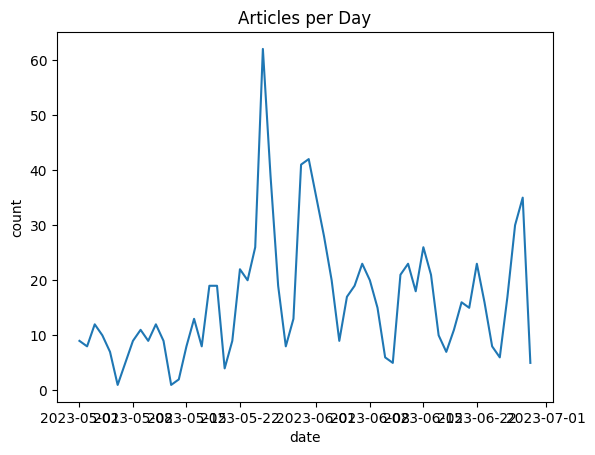

In [ ]:
# SHOW MISSINGNESS + SUSPICIOUS ENTRIES/OUTLIERS
import matplotlib.pyplot as plt

# missingness
miss = df.isna().mean().sort_values(ascending=False)
display((miss * 100).rename("missing_%").to_frame())

if df["description"].isna().any():
    display(df["description"].isna().groupby(df["publisher_cluster"]).mean().rename("missing_description_rate"))

# sentiment outliers (VADER should be within [-1, 1])
print("sentiment_score range:", df["sentiment_score"].min(), df["sentiment_score"].max())
display(df[(df["sentiment_score"] < -1) | (df["sentiment_score"] > 1)].head())

# duplicate URLs
print("duplicate article_url count:", df["article_url"].duplicated().sum())

df.groupby("date").size().plot()
plt.title("Articles per Day")
plt.ylabel("count")
plt.show()


In [ ]:
# SAVE FINAL CLEANED COPY 
clean = df.copy()
# drop the column insights because it is null, anyways. as shown in the missingness table above.
if "insights" in clean.columns:
    clean = clean.drop(columns=["insights"])

OUT_PATH = "data/02-processed/stock_sentiment_1000_clustered_with_sentiment.json"
clean.to_json(OUT_PATH, orient="records", indent=2, date_format="iso")

clean.groupby("publisher_cluster")["sentiment_score"].agg(["count","mean","std","min","max"])

,count,mean,std,min,max
publisher_cluster,,,,,
Opinion_Retail,379,0.303635,0.423615,-0.9001,0.9382
Quant_Analyst,240,0.303721,0.408807,-0.9119,0.9217
RealTime_News,363,0.320132,0.543510,-0.9338,0.9961


The dataset is tidy (one row per article, one column per variable), contains minimal missing data & the one column (insights) which is fully empty has been removed, shows no duplicate entries or invalid sentiment values, and has reasonable distributions across time and publisher clusters.

### Historical U.S. Stock Price Dataset (Yahoo Finance, 5-Year Window)

This dataset contains daily stock price and trading activity information for large publicly traded U.S. companies over approximately five years. Each record represents one trading day for a specific company and includes price levels and trading volume. The dataset is structured in a tidy format, where each row represents one observation (ticker–date pair) and each column represents a variable.

Important Metrics & Their Meaning
- Date
    - Trading day (YYYY-MM-DD).
    - Used to align stock price movements with news sentiment timestamps.
- Ticker
    - Unique stock symbol identifying a company.
    - Enables merging with sentiment data tied to specific firms.
- Open (USD)
    - Price at the start of the trading day.
    - Reflects overnight market reactions.
- High & Low (USD)
    - Highest and lowest prices reached during the trading day.
    - Used to measure intraday volatility and price range.
- Close (USD)
    - Final trading price for the day.
    - Often used for technical analysis and daily valuation.
- Adjusted Close (USD)
    - Closing price adjusted for stock splits and dividends.
    - Preferred for calculating returns and long-term performance because it reflects true investor value.
- Volume (shares traded)
    - Total number of shares traded that day.
    - High volume often indicates strong investor interest or reaction to news.

Why These Metrics Matter for This Project
- This project aims to predict stock price movement using news sentiment. The dataset enables calculation of:
    - Daily returns (price change)
    - Price direction (up/down) for classification targets
    - Volatility (risk & uncertainty)
    - Volume spikes indicating market reaction intensity
    - Adjusted Close prices will be used to compute returns because they account for corporate actions.


Dataset Limitations & Concerns
- Several limitations should be considered:
    - The dataset includes primarily large-cap companies, which may bias results toward highly liquid, heavily followed stocks.
    - Data is recorded at a daily frequency, preventing analysis of intraday sentiment reactions.
    - The time span (~5 years) limits long-term economic cycle analysis.
    - It does not include macroeconomic variables (interest rates, inflation), which influence market behavior.
    - Market holidays and non-trading days require alignment when merging with sentiment data.
    - Volume spikes may be influenced by algorithmic trading and not purely investor sentiment.
    
Despite these limitations, daily OHLCV data is the standard foundation for financial prediction models and is appropriate for sentiment-based return prediction.

In [2]:
import pandas as pd

path = "data/00-raw/stock_details_5_years.csv"
stocks = pd.read_csv(path)

stocks.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


The dataset is clean, well-structured, and ready for analysis, with each row representing one company’s trading activity on a specific date and all price and volume fields stored in consistent numeric formats. No invalid values or major missing data were observed, and zeros in the dividends and stock split columns correctly indicate no events rather than missing information. To confirm usability, the Date column was converted to datetime format, numeric fields were verified, and the data was sorted by company and date to ensure proper time-series ordering. Minimal preprocessing was required, aside from computing daily returns and creating a price-direction label to serve as the prediction target. Overall, the dataset required only basic validation and feature preparation before being merged with sentiment data.

## Ethics 
[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 > Yes there can be bias within the news sources, so we will need to cross-check information to ensure bias isn't involved
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 > The data we will use will not contain any personally identifiable information
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 > The data we used is from publicly available newspaper sources.
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 > The sources we use do not contain any personal information of any person
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 > There might be some lesser known sources that are good predictions for the stock market for Nvidia
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 > They will be designed to represent how well each source can predict Nvidia Stock market
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
 > Yes we will record where we get our data

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 > Yes we will ensure that news sources are credible and don't have discriminatory variables
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 > Yes we will be able to explain how the model came to a conclusion based on the news sources it was fed
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 > We aren't anticipating users to be harmed by the results
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 > Yes our model will work one a single-run basis where we run it once to gather the results we need
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

* *We will communicate through an IMessage groupchat, and will meet weekly via zoom*
* *We will all be respectful of each other and communicate in a friendly but professional manor*
* *We will handle conflicts early and will make decisions as a team*
* *Everyone will have assigned tasks and work will be split as evenly as possible*

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 1/28  |  12 PM | Read & Think about COGS 108 expectations; brainstorm topics/questions  | Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| 2/4  |  12 PM |  Start work on project proposal sections | Reviewing project proposal sections and discussing datasets | 
| 2/11  | 12 PM  | Edit, finalize, and submit proposal; Search for datasets  |  find all the relevant datasets & tweak question accordingly if needed |
| 2/18  | 12 PM  | Import Data and finish sentiment analysis for everyone's assigned source; Begin work on Data Checkpoint | review sentiment analysis and discuss next steps; submit Data Checkpoint   |
| 2/25  | 12 PM  | Combine sentiment analysis & come to conclusion | Discuss/edit Analysis; Discuss EDA Checkpoint and steps needed to complete project |
| 3/4  | 12 PM  | Some work on EDA Checkpoint, and most of visualizations done | Submit EDA Checkpoint; Discuss extra experimentation / buffer time in case something went wrong |
| 3/11  | 12 PM  | Finalizing project | Turn in Final Project & Group Project Surveys |